# Setup 💻 (do not forget to run these cells before starting 👇)

## 1. Importing Libraries

In [6]:
import micropip
await micropip.install("matplotlib")
await micropip.install("seaborn")

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Loading Spotify dataset

In [4]:
df = pd.read_csv('data/spotify-dataset.csv')

----------

# Your Assignement starts here 🔥

## 1. Can you display the first 10 row of the dataset? 

In [8]:
df.head(10)


,acousticness,artists,danceability,duration_ms,energy,explicit,id,instrumentalness,key,liveness,loudness,mode,name,popularity,release_date,speechiness,tempo,valence,year
0,0.995,['Carl Woitschach'],0.708,158648,0.1950,0,6KbQ3uYMLKb5jDxLF7wYDD,0.563,10,0.1510,-12.428,1,Singende Bataillone 1. Teil,0,1928,0.0506,118.469,0.7790,1928
1,0.994,"['Robert Schumann', 'Vladimir Horowitz']",0.379,282133,0.0135,0,6KuQTIu1KoTTkLXKrwlLPV,0.901,8,0.0763,-28.454,1,"Fantasiestücke, Op. 111: Più tosto lento",0,1928,0.0462,83.972,0.0767,1928
2,0.604,['Seweryn Goszczyński'],0.749,104300,0.2200,0,6L63VW0PibdM1HDSBoqnoM,0.000,5,0.1190,-19.924,0,Chapter 1.18 - Zamek kaniowski,0,1928,0.9290,107.177,0.8800,1928
3,0.995,['Francisco Canaro'],0.781,180760,0.1300,0,6M94FkXd15sOAOQYRnWPN8,0.887,1,0.1110,-14.734,0,Bebamos Juntos - Instrumental (Remasterizado),0,1928-09-25,0.0926,108.003,0.7200,1928
4,0.990,"['Frédéric Chopin', 'Vladimir Horowitz']",0.210,687733,0.2040,0,6N6tiFZ9vLTSOIxkj8qKrd,0.908,11,0.0980,-16.829,1,"Polonaise-Fantaisie in A-Flat Major, Op. 61",1,1928,0.0424,62.149,0.0693,1928
5,0.995,"['Felix Mendelssohn', 'Vladimir Horowitz']",0.424,352600,0.1200,0,6NxAf7M8DNHOBTmEd3JSO5,0.911,6,0.0915,-19.242,0,Scherzo a capriccio: Presto,0,1928,0.0593,63.521,0.2660,1928
6,0.956,"['Franz Liszt', 'Vladimir Horowitz']",0.444,136627,0.1970,0,6O0puPuyrxPjDTHDUgsWI7,0.435,11,0.0744,-17.226,1,"Valse oubliée No. 1 in F-Sharp Major, S. 215/1",0,1928,0.0400,80.495,0.3050,1928
7,0.988,['Carl Woitschach'],0.555,153967,0.4210,0,6OJjveoYwJdIt76y0Pxpxw,0.836,1,0.1050,-9.878,1,Per aspera ad astra,0,1928,0.0474,123.310,0.8570,1928
8,0.995,"['Francisco Canaro', 'Charlo']",0.683,162493,0.2070,0,6OaJ8Bh7lsBeYoBmwmo2nh,0.206,9,0.3370,-9.801,0,Moneda Corriente - Remasterizado,0,1928-10-03,0.1270,119.833,0.4930,1928
9,0.846,['Seweryn Goszczyński'],0.674,111600,0.2050,0,6PrZexNb16cabXR8Q418Xc,0.000,9,0.1700,-20.119,1,Chapter 1.3 - Zamek kaniowski,0,1928,0.9540,81.249,0.7590,1928


## 2. Are there any missing values in the dataset?

In [9]:
df.isna().sum()


acousticness        0
artists             0
danceability        0
duration_ms         0
energy              0
explicit            0
id                  0
instrumentalness    0
key                 0
liveness            0
loudness            0
mode                0
name                0
popularity          0
release_date        0
speechiness         0
tempo               0
valence             0
year                0
dtype: int64

## 3. How many songs are there in the dataset?

In [10]:
df.shape[0]


169909

## 4. How many artists?

In [7]:
df.columns
df['artists'].nunique()


33375

## 5. What's the average duration of a song, in minutes?

In [8]:
avg_duration_min = df['duration_ms'].mean() / (1000 * 60)
avg_duration_min


np.float64(3.856769316222213)

## 6. Can you plot the distribution of the durations?

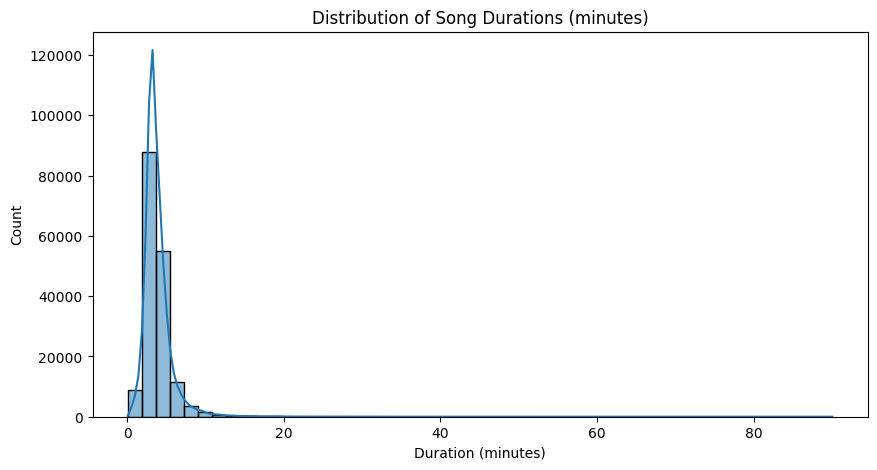

In [9]:
# Convert duration from ms → minutes
df['duration_min'] = df['duration_ms'] / (1000 * 60)

plt.figure(figsize=(10,5))
sns.histplot(df['duration_min'], bins=50, kde=True)
plt.title("Distribution of Song Durations (minutes)")
plt.xlabel("Duration (minutes)")
plt.ylabel("Count")
plt.show()


## 7. [Follow-up] Can you make this plot more readable by removing outliers (extreme values)?

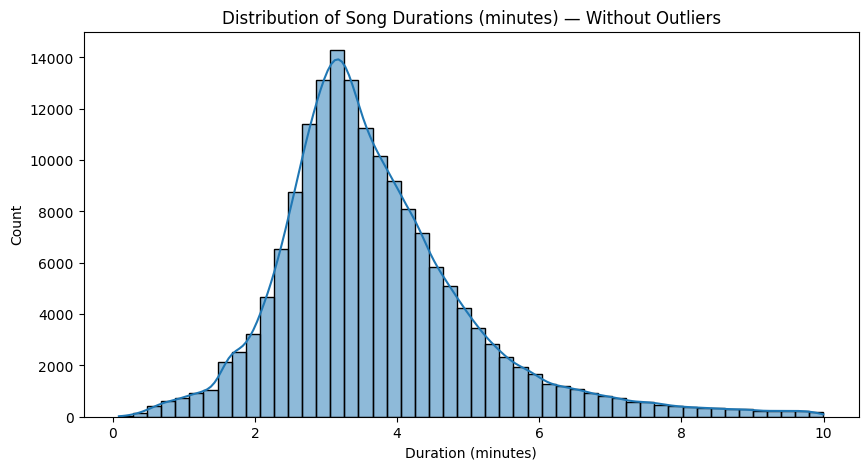

In [11]:
# Remove songs longer than 10 minutes (600,000 ms)
df_clean = df[df['duration_ms'] < 600000].copy()

# Convert duration to minutes safely
df_clean['duration_min'] = df_clean['duration_ms'] / (1000 * 60)

plt.figure(figsize=(10,5))
sns.histplot(df_clean['duration_min'], bins=50, kde=True)
plt.title("Distribution of Song Durations (minutes) — Without Outliers")
plt.xlabel("Duration (minutes)")
plt.ylabel("Count")
plt.show()


We only remove 470 songs (out of almost 170k) and get a way more interesting plot!

## 8. What are the top 10 longest songs (duration)?

In [13]:
df.sort_values(by='duration_ms', ascending=False).head(10)


,acousticness,artists,danceability,duration_ms,energy,explicit,id,instrumentalness,key,liveness,loudness,mode,name,popularity,release_date,speechiness,tempo,valence,year,duration_min
7411,0.111000,['Sound Dreamer'],0.0000,5403500,0.000099,0,7foc25ig7dibxvULPU2kBG,0.392000,2,0.1370,-21.669,1,Brown Noise - 90 Minutes,50,2013-06-05,0.0000,0.000,0.000000,2013,90.058333
46972,0.975000,['Sounds for Life'],0.1530,4270034,0.079200,0,605JTCltCe1IcqrGXQ294K,1.000000,10,0.1130,-23.962,0,Brown Noise for Sleep,42,2009-03-15,0.1250,132.904,0.000537,2009,71.167233
54511,0.000385,"['Lightning, Thunder and Rain Storm']",0.1160,4269407,0.338000,0,7dYf0CsWHDLvlP6HJPs3zO,0.093500,1,0.3420,-36.638,1,Midnight Thunderstorm Part 2,44,2009-09-22,0.0648,94.453,0.029300,2009,71.156783
54675,0.932000,['Ocean Sounds'],0.0797,4120258,0.995000,0,2QfFLpSGF1T1pY6tq4kD7Z,0.562000,1,0.3100,-17.379,1,Ocean Waves Sounds,44,2010-07-16,0.0612,84.788,0.000010,2010,68.670967
125152,0.932000,['Ocean Waves For Sleep'],0.0797,4120258,0.995000,0,1saXdvEAafdRzUphXBzSHg,0.562000,1,0.3100,-17.379,1,Ocean Waves for Sleep,55,2010-07-16,0.0612,84.788,0.000010,2010,68.670967
38491,0.003670,['Sleep'],0.1600,3816373,0.572000,0,1vhvheW4R0KbK6Kr3NFplW,0.745000,5,0.0952,-6.949,1,Dopesmoker,43,2003,0.0321,96.926,0.093200,2003,63.606217
140784,0.976000,['Brian Eno'],0.0918,3650800,0.056900,0,4t3Yh6tKkxXrc458pNI7zZ,0.884000,0,0.0842,-31.808,1,Thursday Afternoon - 2005 Digital Remaster,39,1985-10-01,0.0358,81.944,0.052800,1985,60.846667
72889,0.601000,['Environments'],0.1590,3557955,0.562000,0,2rRuuVflvA23Fcl8KezNAF,0.611000,10,0.1070,-22.135,0,The Psychologically Ultimate Seashore (16 rpm),19,1969-01-01,0.1600,129.863,0.012600,1969,59.299250
10573,0.900000,['Umm Kulthum'],0.4100,3551152,0.451000,0,0AsT5HMyXuqa8qWMLv0YZb,0.000034,8,0.7030,-10.213,0,Enta Oumry,26,1964-02-06,0.1260,118.125,0.408000,1964,59.185867
118777,0.891000,['Umm Kulthum'],0.3450,3523619,0.723000,0,1gXsu5iZHLpUr1zvXEfOxw,0.769000,9,0.3930,-7.801,1,Naheg El Berda,0,1946-01-01,0.0996,115.550,0.299000,1946,58.726983


## 9. How long would it take to listen to all the songs?

In [14]:
total_ms = df['duration_ms'].sum()

total_hours = total_ms / (1000 * 60 * 60)
total_days = total_hours / 24

print("Total listening time (hours):", round(total_hours, 2))
print("Total listening time (days):", round(total_days, 2))


Total listening time (hours): 10921.66
Total listening time (days): 455.07


This length is expressed in milliseconds, let's convert to days!

## 10. What are the top 10 most popular songs? We would like a DataFrame with only the columns `artists`, `name` and `popularity` as output!

In [17]:
df.columns
df[['artists', 'name', 'popularity']] \
    .sort_values(by='popularity', ascending=False) \
    .head(10)



,artists,name,popularity
87942,['The Weeknd'],Blinding Lights,100
87940,"['DaBaby', 'Roddy Ricch']",ROCKSTAR (feat. Roddy Ricch),99
87949,"['Powfu', 'beabadoobee']",death bed (coffee for your head) (feat. beabad...,97
87941,"['THE SCOTTS', 'Travis Scott', 'Kid Cudi']",THE SCOTTS,96
87852,"['Surf Mesa', 'Emilee']",ily (i love you baby) (feat. Emilee),95
87946,['Drake'],Toosie Slide,95
87840,['Roddy Ricch'],The Box,95
87844,"['BENEE', 'Gus Dapperton']",Supalonely,95
87943,['StaySolidRocky'],Party Girl,94
87951,['6ix9ine'],GOOBA,94


## 11. What is the most popular song before 2000?

In [18]:
df[df['year'] < 2000][['artists', 'name', 'popularity', 'year']] \
    .sort_values(by='popularity', ascending=False) \
    .head(1)


,artists,name,popularity,year
84241,['The Police'],Every Breath You Take,83,1983


## 12. Can you plot the distribution of `popularity`?

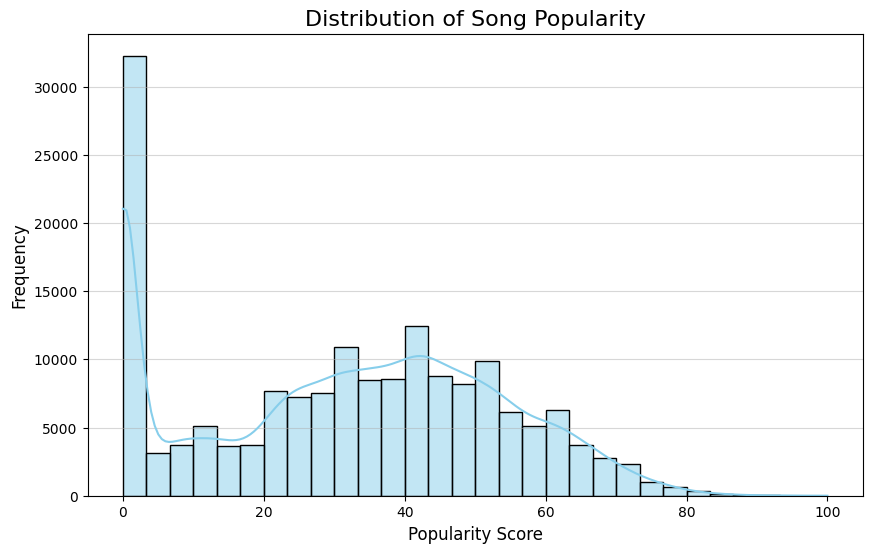

In [19]:
plt.figure(figsize=(10, 6))
sns.histplot(df['popularity'], kde=True, bins=30, color='skyblue')
plt.title('Distribution of Song Popularity', fontsize=16)
plt.xlabel('Popularity Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.5)
plt.show()

## 13. What are the top 10 artists in terms of number of songs?

Top 10 Artists by Number of Songs:
artists
['Эрнест Хемингуэй']      1215
['Francisco Canaro']       938
['Эрих Мария Ремарк']      781
['Ignacio Corsini']        620
['Frank Sinatra']          592
['Bob Dylan']              539
['The Rolling Stones']     512
['Johnny Cash']            502
['The Beach Boys']         491
['Elvis Presley']          488
Name: count, dtype: int64


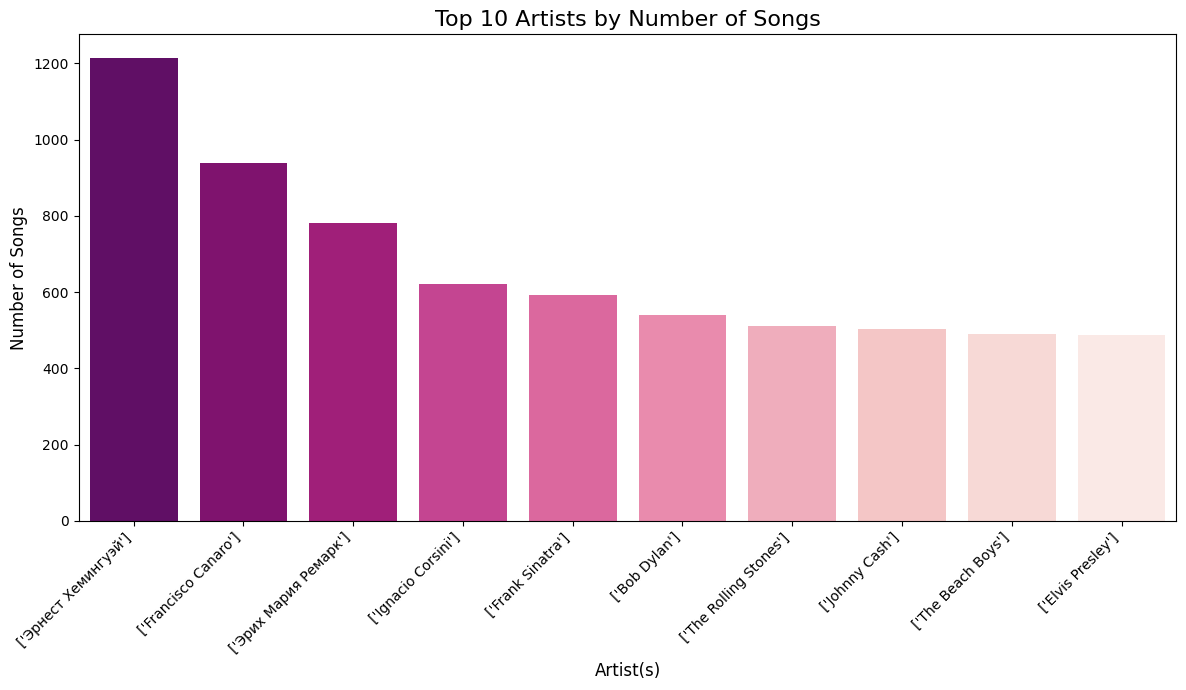

In [12]:
# Find the top 10 artists by counting the occurrences in the 'artists' column
top_10_artists = df['artists'].value_counts().head(10)

print("Top 10 Artists by Number of Songs:")
print(top_10_artists)

# Plot the results for a better visual
plt.figure(figsize=(12, 7))

# --- CORRECTED BARPLOT CODE ---
# Assigning 'hue' to the x-variable and setting 'legend=False' addresses the FutureWarning.
sns.barplot(
    x=top_10_artists.index, 
    y=top_10_artists.values, 
    hue=top_10_artists.index,  # Explicitly set hue to x-variable
    palette='RdPu_r',
    legend=False                # Hide the redundant legend
)
# -----------------------------

plt.title('Top 10 Artists by Number of Songs', fontsize=16)
plt.xlabel('Artist(s)', fontsize=12)
plt.ylabel('Number of Songs', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 14. [Follow-up] can you make a bar chart out of this result?

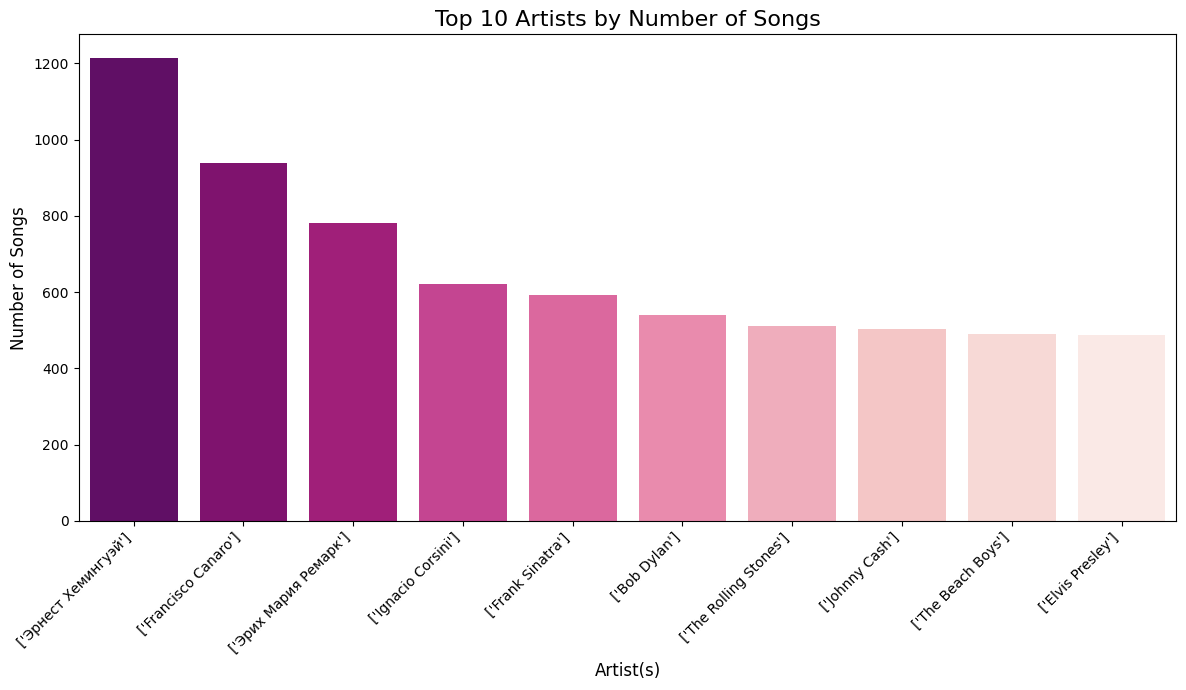

In [13]:
# 1. Calculate the top 10 artists (from Q 2.13)
top_10_artists = df['artists'].value_counts().head(10)

# 2. Plot a bar chart (Q 2.14)
plt.figure(figsize=(12, 7))

# Use the recommended syntax to avoid the FutureWarning
sns.barplot(
    x=top_10_artists.index,
    y=top_10_artists.values,
    hue=top_10_artists.index,  # Explicitly set hue to the x-variable
    palette='RdPu_r',
    legend=False                # Hide the redundant legend
)

plt.title('Top 10 Artists by Number of Songs', fontsize=16)
plt.xlabel('Artist(s)', fontsize=12)
plt.ylabel('Number of Songs', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 15. How many songs by key?

In [14]:
songs_by_key = df['key'].value_counts()
print("Number of songs by musical key:")
print(songs_by_key)

Number of songs by musical key:
key
0     21499
7     20757
2     18821
9     17628
5     16336
4     12921
1     12816
10    12056
8     10711
11    10593
6      8586
3      7185
Name: count, dtype: int64


## 16. [Follow-up] Can you plot a bar chart using Seaborn? Make sure the keys are sorted in a descending order.

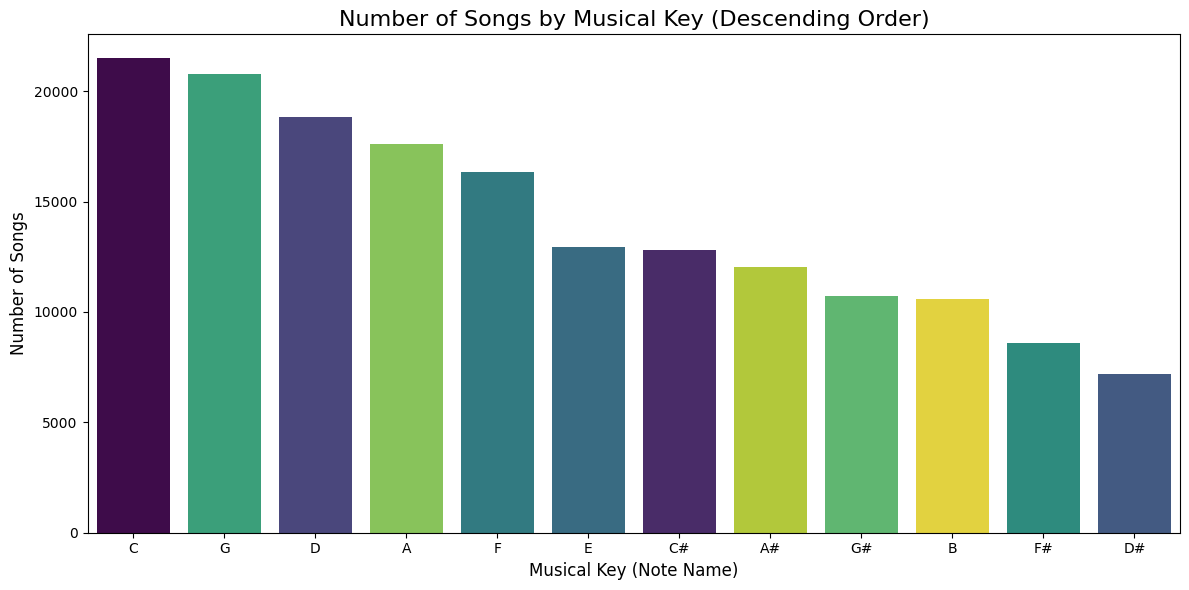

In [16]:
songs_by_key_sorted = df['key'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(12, 6))

# 1. Corrected sns.barplot call to fix FutureWarning
ax = sns.barplot(
    x=songs_by_key_sorted.index,
    y=songs_by_key_sorted.values,
    hue=songs_by_key_sorted.index, # Explicitly set hue to x-variable
    palette='viridis',
    order=songs_by_key_sorted.index,
    legend=False                # Hide the redundant legend
)

# Map key numbers to note names for better readability
key_map = {
    0: 'C', 1: 'C#', 2: 'D', 3: 'D#', 4: 'E',
    5: 'F', 6: 'F#', 7: 'G', 8: 'G#', 9: 'A',
    10: 'A#', 11: 'B'
}
x_labels = [key_map[key] for key in songs_by_key_sorted.index]

# 2. Corrected tick label setting to fix UserWarning
# Explicitly set tick locations before setting labels
ax.set_xticks(range(len(x_labels)))
ax.set_xticklabels(x_labels)

plt.title('Number of Songs by Musical Key (Descending Order)', fontsize=16)
plt.xlabel('Musical Key (Note Name)', fontsize=12)
plt.ylabel('Number of Songs', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 17. Can you plot a line graph representing the annual number of songs since 1921?

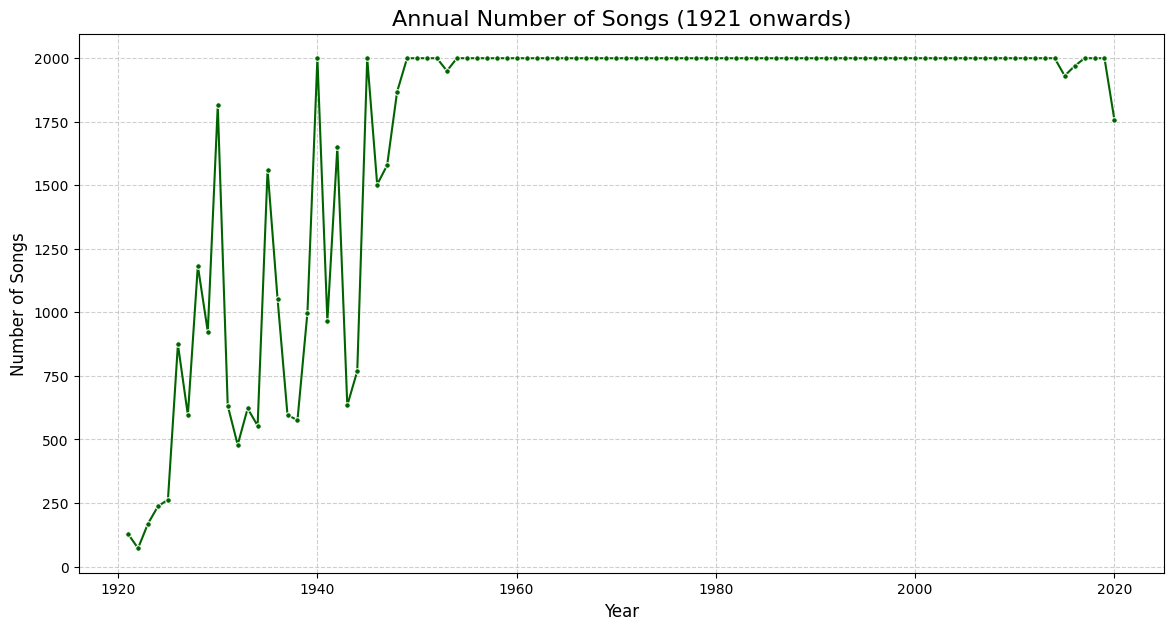

In [17]:
# Your code goes here 💪
# Filter data from 1921 onwards
df_since_1921 = df[df['year'] >= 1921]

# Count the number of songs per year and sort by year
annual_song_count = df_since_1921['year'].value_counts().sort_index()

plt.figure(figsize=(14, 7))
sns.lineplot(x=annual_song_count.index, y=annual_song_count.values, color='darkgreen', marker='o', markersize=4)
plt.title('Annual Number of Songs (1921 onwards)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Songs', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Last question! 👇

## 18. Can you visually check if there is relationship between `year` and `popularity`?

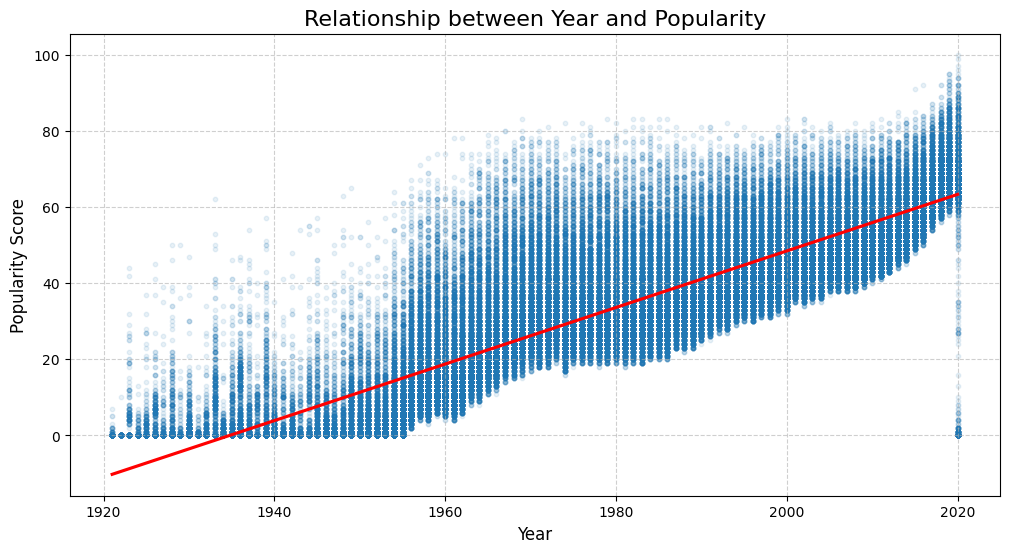

In [18]:
plt.figure(figsize=(12, 6))
# Use a regression plot to show the scatter points and an estimated linear relationship (trend line)
sns.regplot(
    x=df['year'],
    y=df['popularity'],
    scatter_kws={'alpha':0.1, 's':10}, # Reduced transparency and size for better visualization of dense data
    line_kws={'color':'red'}
)
plt.title('Relationship between Year and Popularity', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Popularity Score', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

It seems that the popularity score has increased through time....